# Tutorial 6: Atlas-free 3D CNN inference

Use the same task/family/domain selectors for released checkpoints or a local standardized run. Mixed-baseline CNN weights are always the default; `variant="finetuned"` is an explicit opt-in.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from neurovlm import AtlasFreeCNNDataProvider
from neurovlm.atlas_free_text import (
    AtlasFreeContrastiveCollator,
    AtlasFreeTextEmbeddingLookup,
    primary_positive_text,
    primary_positive_text_id,
)
from neurovlm.runtime import load_pipeline

DOMAIN = "pubmed"  # pubmed | nilearn | neurovault
INFERENCE_EXAMPLES = 2
TOP_K = 5

provider = AtlasFreeCNNDataProvider(domain=DOMAIN)
test_data = provider.test
rows = [test_data[index] for index in range(min(INFERENCE_EXAMPLES, len(test_data)))]
text_lookup = AtlasFreeTextEmbeddingLookup.published()
batch = AtlasFreeContrastiveCollator(
    text_lookup, (36, 45, 38)
)(rows)
QUERY_INDEX = 0
query_volume = batch["volume"][QUERY_INDEX, 0].cpu()
query_slice_index = int(query_volume.abs().sum(dim=(0, 1)).argmax())

## Reconstruction

Pass a batch of atlas-free volumes to the autoencoder. The returned tensor has the same shape as the input; the example also computes a simple batch MSE.

In [2]:
autoencoder = load_pipeline(family="cnn", task="autoencoder")
reconstructed = autoencoder.reconstruct(batch["volume"]).cpu()
{
    "model": autoencoder.metadata.canonical_name,
    "input_shape": tuple(batch["volume"].shape),
    "output_shape": tuple(reconstructed.shape),
    "batch_mse": float((reconstructed - batch["volume"]).square().mean()),
}

{'model': 'cnn:autoencoder:mixed_baseline',
 'input_shape': (2, 1, 36, 45, 38),
 'output_shape': (2, 1, 36, 45, 38),
 'batch_mse': 0.0002749354171101004}

### Original and reconstructed volume

The axial slice with the greatest absolute input activation is shown for both volumes with a shared color scale.

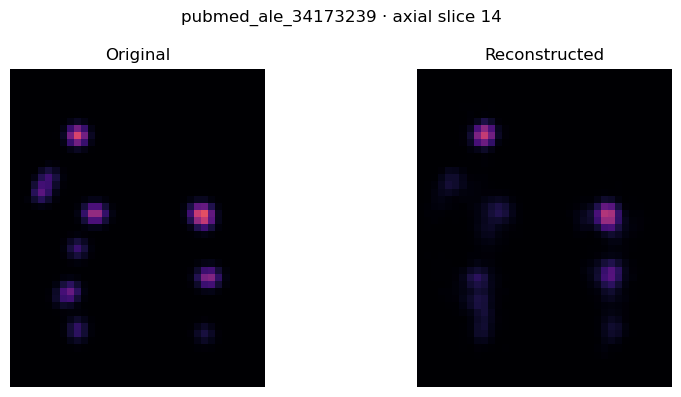

In [3]:
query_reconstruction = reconstructed[QUERY_INDEX, 0]
display_max = float(max(query_volume.max(), query_reconstruction.max()))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(
    query_volume[:, :, query_slice_index].T,
    cmap="magma", origin="lower", vmin=0, vmax=display_max,
)
axes[0].set_title("Original")
axes[1].imshow(
    query_reconstruction[:, :, query_slice_index].T,
    cmap="magma", origin="lower", vmin=0, vmax=display_max,
)
axes[1].set_title("Reconstructed")
for ax in axes:
    ax.axis("off")
fig.suptitle(f'{batch["map_id"][QUERY_INDEX]} · axial slice {query_slice_index}')
fig.tight_layout()
plt.show()

## Contrastive retrieval

Use one brain volume as an image query and rank every text in the selected domain's complete test split. The table shows the five highest cosine similarities and marks whether the known paired text was recovered.

In [4]:
contrastive = load_pipeline(
    family="cnn", task="contrastive", domain=DOMAIN
)
candidate_rows = test_data.rows
text_lookup.validate_dataset(candidate_rows)
candidate_text_ids = [primary_positive_text_id(row) for row in candidate_rows]
candidate_text_embeddings = torch.stack([
    text_lookup[text_id] for text_id in candidate_text_ids
])

query_scores = contrastive.similarity(
    batch["volume"][QUERY_INDEX:QUERY_INDEX + 1],
    candidate_text_embeddings,
).cpu()[0]
top_scores, top_indices = query_scores.topk(min(TOP_K, len(query_scores)))

paired_text_id = batch["text_id"][QUERY_INDEX]
paired_text = primary_positive_text(rows[QUERY_INDEX])
print(f'Query map: {batch["map_id"][QUERY_INDEX]}')
print(f'Known paired text ({paired_text_id}):\n{paired_text}\n')

ranking = pd.DataFrame([
    {
        "rank": rank,
        "text_id": candidate_text_ids[int(text_index)],
        "cosine_similarity": float(score),
        "is_known_pair": candidate_text_ids[int(text_index)] == paired_text_id,
        "text": primary_positive_text(candidate_rows[int(text_index)]),
    }
    for rank, (score, text_index) in enumerate(zip(top_scores, top_indices), start=1)
])
pd.set_option("display.max_colwidth", 120)
ranking

Query map: pubmed_ale_34173239
Known paired text (pubmed_ale_34173239::pair_0):
Enhanced insightfulness and neural activation induced by metaphorical solutions to appropriate mental distress problems. [SEP] During mental distress, creative solutions that are both novel and appropriate can enhance therapeutic insightfulness. This process involves the activation of key brain regions, including the bilateral hippocampus and amygdala, which are involved in episodic memory encoding. The right superior frontal gyrus and left superior/middle temporal gyrus also play a role in processing novel and appropriate solutions. Additionally, the bilateral inferior frontal gyrus, fusiform gyrus, and inferior/middle occipital gyrus are activated when solutions are novel, suggesting involvement in language processing and visual perception. Furthermore, the left inferior parietal lobule is activated when solutions are appropriate, indicating its role in processing and integrating relevant information.



,rank,text_id,cosine_similarity,is_known_pair,text
0,1,pubmed_ale_29414129::pair_0,0.402916,False,Neural correlates of intimate picture stimuli in females. [SEP] When females are exposed to intimate picture stimuli...
1,2,pubmed_ale_19015078::pair_0,0.386429,False,The neural correlates of trait resilience when anticipating and recovering from threat. [SEP] When anticipating and ...
2,3,pubmed_ale_19428403::pair_0,0.374501,False,A left amygdala mediated network for rapid orienting to masked fearful faces. [SEP] When individuals encounter poten...
3,4,pubmed_ale_32633448::pair_0,0.370082,False,"Negative content enhances stimulus‐specific cerebral activity during free viewing of pictures, faces, and words [SEP..."
4,5,pubmed_ale_28943856::pair_0,0.369148,False,Gender Differences in the Perception of Personalized Half-Nude Female Bodies [SEP] When viewing half-nude female bod...


### Image used as the retrieval query

This is the same input volume whose known paired text and top-five retrieved texts are shown above.

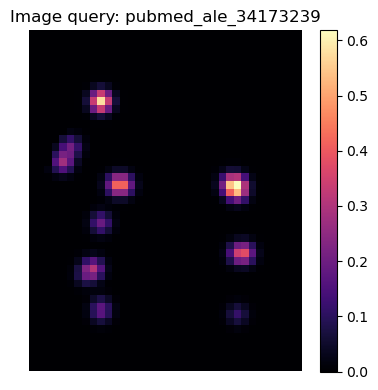

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(
    query_volume[:, :, query_slice_index].T,
    cmap="magma", origin="lower",
)
ax.set_title(f'Image query: {batch["map_id"][QUERY_INDEX]}')
ax.axis("off")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Text-to-brain generation

Generate one volume per text embedding. The summary confirms the concrete output shape and value range.

In [6]:
generator = load_pipeline(
    family="cnn", task="text_to_brain", domain=DOMAIN
)
generated = generator.generate(batch["text_embedding"]).cpu()
{
    "model": generator.metadata.canonical_name,
    "text_ids": batch["text_id"],
    "output_shape": tuple(generated.shape),
    "value_range": (float(generated.min()), float(generated.max())),
}

{'model': 'cnn:text_to_brain:pubmed:mixed_baseline',
 'text_ids': ['pubmed_ale_34173239::pair_0', 'pubmed_ale_23418930::pair_0'],
 'output_shape': (2, 1, 36, 45, 38),
 'value_range': (-0.04848608002066612, 0.09427356719970703)}

### Inspect a generated map

A center slice gives a quick qualitative check of the generated map beside its paired target.

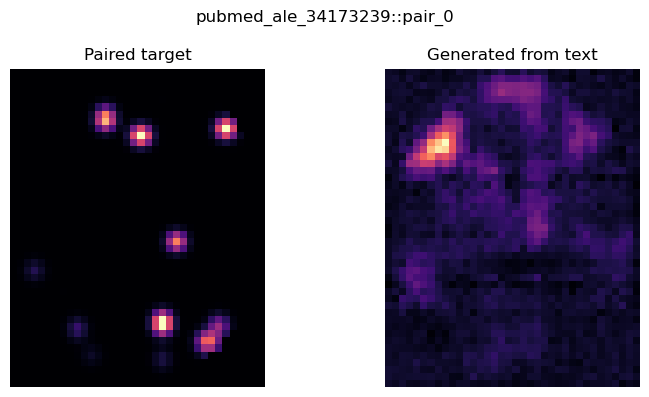

In [7]:
slice_index = generated.shape[-1] // 2
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(batch["volume"][0, 0, :, :, slice_index].T, cmap="magma", origin="lower")
axes[0].set_title("Paired target")
axes[1].imshow(generated[0, 0, :, :, slice_index].T, cmap="magma", origin="lower")
axes[1].set_title("Generated from text")
for ax in axes:
    ax.axis("off")
fig.suptitle(batch["text_id"][0])
fig.tight_layout()
plt.show()

## Local runs and explicit fine-tuning

Load a standardized run with `load_pipeline(..., from_run="runs/...")`. To request released domain-fine-tuned CNN weights, add `variant="finetuned"`. MLP uses the same loader with `family="mlp"`; the original `NeuroVLM` interface remains available for legacy high-level workflows.